In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 读取清洗后的数据
df = pd.read_csv(r'D:\My_First_Project\src\data\cleaned_user_data.csv')

# 查看数据概况
print(df.shape)
df.head()

(50000, 13)


,Churned,Membership_Years,Signup_Quarter,Login_Frequency,Session_Duration_Avg,Total_Purchases,Days_Since_Last_purchase,Average_Order_Value,Cart_Abandonment_Rate,Customer_Service_calls,Returns_Rate,Discount_Usage_Rate,Product_Reviews_Written
0,0,2.9,Q1,14.0,27.4,9.0,34.0,94.72,50.6,9.0,2.0,46.40,4.0
1,0,1.6,Q4,15.0,42.7,19.5,71.0,82.45,37.7,7.0,9.2,57.96,3.0
2,0,2.9,Q4,10.0,24.8,9.1,11.0,165.52,70.9,4.0,11.5,12.24,1.0
3,0,2.6,Q1,10.0,38.4,15.0,47.0,147.33,41.7,2.0,5.4,44.10,5.0
4,0,3.1,Q4,29.0,51.4,32.5,73.0,141.30,19.1,1.0,5.5,25.20,11.0


In [11]:
# 按 Churned 分组，计算均值
profile = df.select_dtypes(include=[np.number]).groupby('Churned').mean().T
profile.columns = ['未流失', '流失']
profile['差异'] = profile['流失'] - profile['未流失']
profile['差异百分比'] = (profile['差异'] / profile['未流失']) * 100
profile = profile.round(2)
print(profile)
profile.to_csv(r'D:\My_First_Project\src\outputs\churn_profile.csv')

                             未流失      流失     差异  差异百分比
Membership_Years            2.98    2.98  -0.00  -0.09
Login_Frequency            12.64    9.12  -3.52 -27.86
Session_Duration_Avg       29.21   23.69  -5.52 -18.90
Total_Purchases            13.83   11.35  -2.48 -17.92
Days_Since_Last_purchase   26.89   36.94  10.05  37.37
Average_Order_Value       118.38  134.76  16.38  13.84
Cart_Abandonment_Rate      54.19   64.18   9.98  18.42
Customer_Service_calls      5.19    6.90   1.72  33.15
Returns_Rate                6.47    7.20   0.74  11.36
Discount_Usage_Rate        43.05   39.42  -3.63  -8.43
Product_Reviews_Written     3.12    2.19  -0.93 -29.85


In [4]:
# 分别排序正向差异（流失 > 未流失）和负向差异（流失 < 未流失）
positive_diff = profile[profile['差异'] > 0].sort_values('差异', ascending=False)
negative_diff = profile[profile['差异'] < 0].sort_values('差异', ascending=True)
print(positive_diff[['未流失', '流失', '差异', '差异百分比']])
print(negative_diff[['未流失', '流失', '差异', '差异百分比']])

                             未流失      流失     差异  差异百分比
Average_Order_Value       118.38  134.76  16.38  13.84
Days_Since_Last_purchase   26.89   36.94  10.05  37.37
Cart_Abandonment_Rate      54.19   64.18   9.98  18.42
Customer_Service_calls      5.19    6.90   1.72  33.15
Returns_Rate                6.47    7.20   0.74  11.36
                           未流失     流失    差异  差异百分比
Session_Duration_Avg     29.21  23.69 -5.52 -18.90
Discount_Usage_Rate      43.05  39.42 -3.63  -8.43
Login_Frequency          12.64   9.12 -3.52 -27.86
Total_Purchases          13.83  11.35 -2.48 -17.92
Product_Reviews_Written   3.12   2.19 -0.93 -29.85


In [5]:
# 保存结果
positive_diff.to_csv(r'D:\My_First_Project\src\outputs\positive_diff.csv', index=True)
negative_diff.to_csv(r'D:\My_First_Project\src\outputs\negative_diff.csv', index=True)

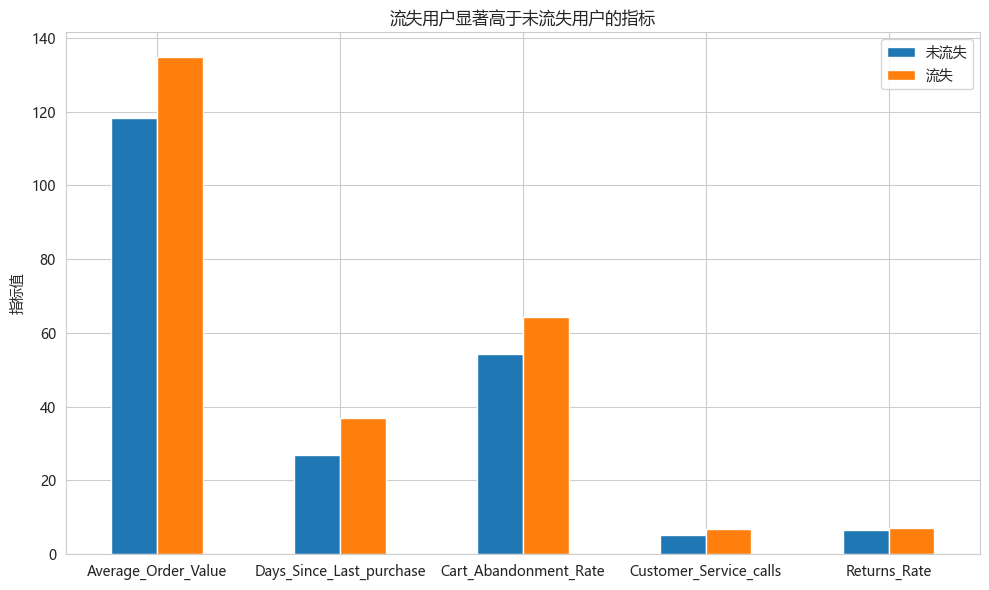

In [6]:
# 绘制正向差异（流失>未流失）柱状图
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
positive_diff[['未流失', '流失']].plot(kind='bar', figsize=(10, 6))
plt.title('流失用户显著高于未流失用户的指标')
plt.ylabel('指标值')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/positive_diff_churn.png')
plt.show()

与流失正相关的指标（越大概率越高）:
Churned                     1.000000
Customer_Service_calls      0.291103
Cart_Abandonment_Rate       0.277963
Days_Since_Last_purchase    0.153360
Returns_Rate                0.054189
Average_Order_Value         0.042288
Name: Churned, dtype: float64


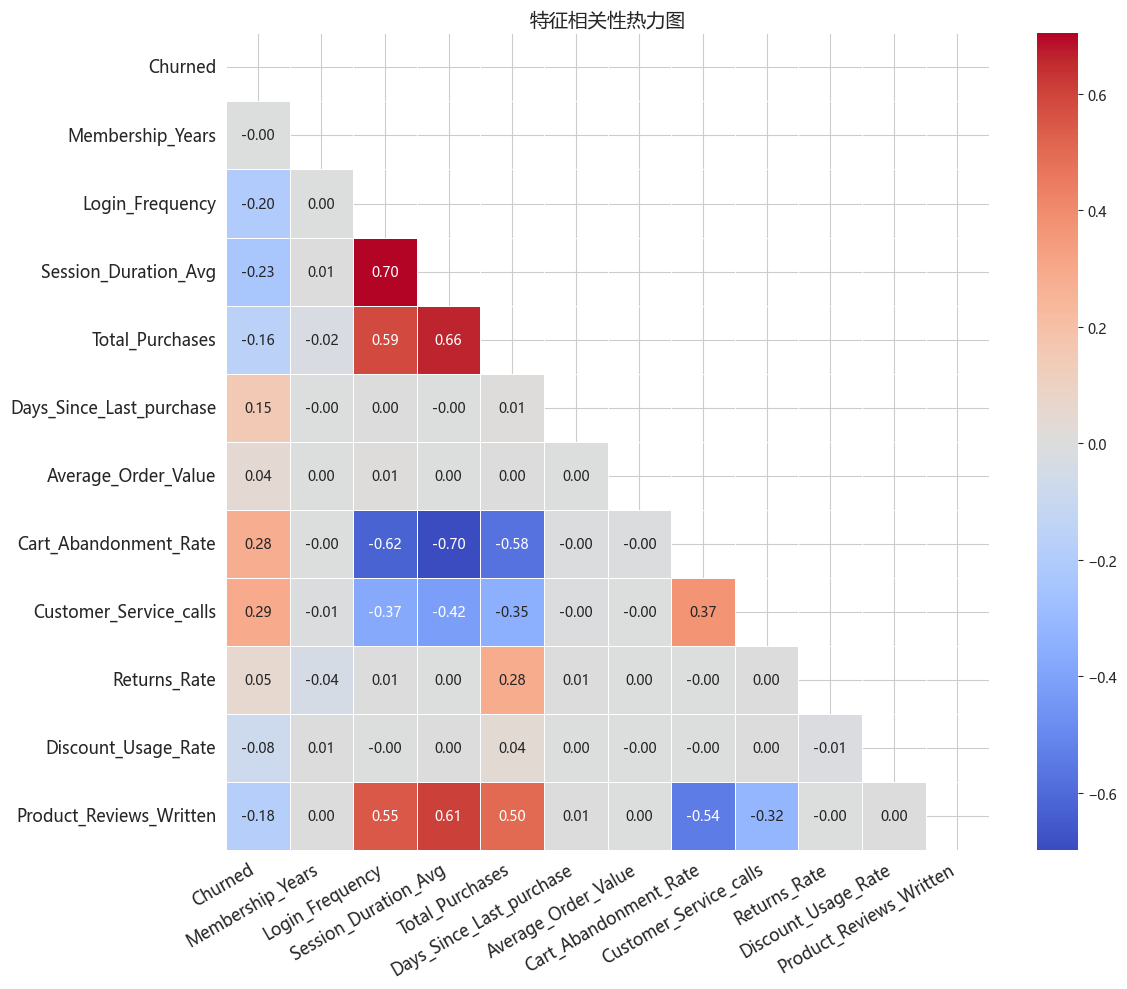

In [7]:
# 相关性分析
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()
churn_corr = corr_matrix['Churned'].sort_values(ascending=False)  # 正值表示正相关
print("与流失正相关的指标（越大概率越高）:")
print(churn_corr[churn_corr > 0])

# 热力图
plt.figure(figsize=(12,10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, linecolor='white')
plt.xticks(rotation=30,ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('特征相关性热力图',fontsize=14)
plt.tight_layout()
plt.savefig('../images/corr_heatmap.png', dpi=150)
plt.show()

In [13]:
p33 = df['Total_Purchases'].quantile(0.33)
p67 = df['Total_Purchases'].quantile(0.67)
df['purchase_tier'] = pd.cut(df['Total_Purchases'],
                              bins=[-np.inf, p33, p67, np.inf],
                              labels=['低频', '中频', '高频'])

p33_aov = df['Average_Order_Value'].quantile(0.33)
p67_aov = df['Average_Order_Value'].quantile(0.67)
df['aov_tier'] = pd.cut(df['Average_Order_Value'],
                        bins=[-np.inf, p33_aov, p67_aov, np.inf],
                        labels=['低客单', '中客单', '高客单'])
# 计算每个分组的流失率
segment_churn = df.groupby(['purchase_tier', 'aov_tier'], observed=False)['Churned'].mean().unstack()
segment_churn = segment_churn.round(2)
print("用户分层流失率矩阵：")
print(segment_churn)
segment_churn.to_csv(r'D:\My_First_Project\src\outputs\segment_churn1.csv')

用户分层流失率矩阵：
aov_tier        低客单   中客单   高客单
purchase_tier                  
低频             0.38  0.37  0.41
中频             0.14  0.16  0.37
高频             0.12  0.23  0.35


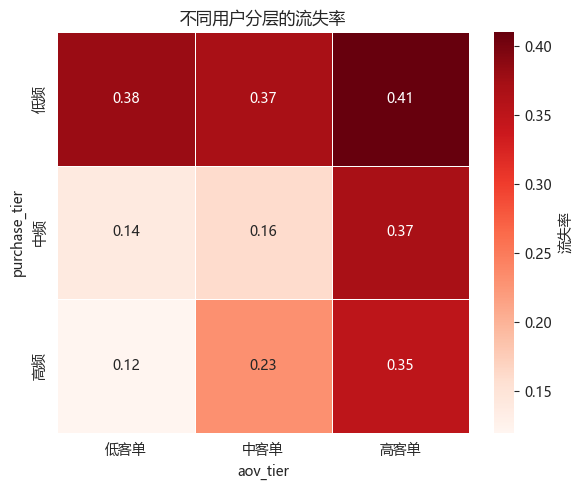

In [9]:
# 可视化（热力图）
plt.figure(figsize=(6,5))
sns.heatmap(segment_churn, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, linecolor='white', cbar_kws={'label': '流失率'})
plt.title('不同用户分层的流失率')
plt.tight_layout()
plt.savefig('../images/segment_churn1_heatmap.png', dpi=150)
plt.show()

service_tier   少客服   中客服   多客服
abandon_tier                  
低弃购           0.10  0.33  0.53
中弃购           0.10  0.25  0.33
高弃购           0.33  0.47  0.61


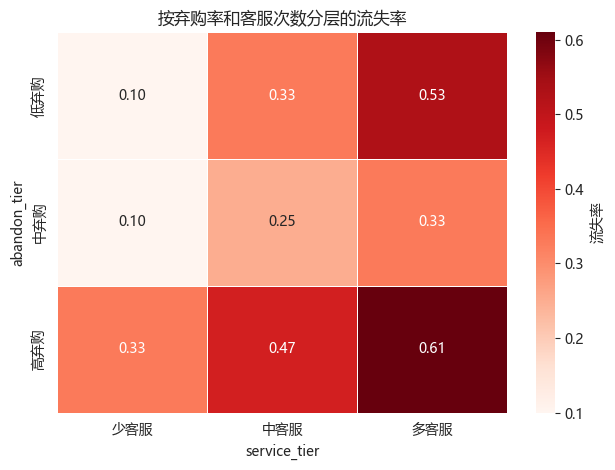

In [12]:
# 按弃购率分三组（低、中、高）
df['abandon_tier'] = pd.cut(df['Cart_Abandonment_Rate'],
                            bins=[0, 33, 67, 100],
                            labels=['低弃购', '中弃购', '高弃购'])

# 按客服次数分三组
df['service_tier'] = pd.cut(df['Customer_Service_calls'],
                            bins=[0, df['Customer_Service_calls'].quantile(0.33),
                                  df['Customer_Service_calls'].quantile(0.67), float('inf')],
                            labels=['少客服', '中客服', '多客服'])
# 计算每组的流失率
segment_churn2 = df.groupby(['abandon_tier', 'service_tier'], observed=False)['Churned'].mean().unstack()
segment_churn2 = segment_churn2.round(2)
print(segment_churn2)
segment_churn2.to_csv(r'D:\My_First_Project\src\outputs\segment_churn2.csv')
# 热力图
sns.heatmap(segment_churn2, annot=True, fmt='.2f', cmap='Reds', linewidths=0.5, linecolor='white', cbar_kws={'label': '流失率'})
plt.title('按弃购率和客服次数分层的流失率')
plt.tight_layout()
plt.savefig('../images/segment_churn2_heatmap.png', dpi=150)
plt.show()